<a href="https://colab.research.google.com/github/GGPwis/Procesamiento-del-Habla/blob/main/Portal_Gustavo_TP1_webscrapping_preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[PORTAL, GUSTAVO GABRIEL]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


Instalamos las librerias necesarias para desarrollar el tp.

`requests` se utiliza para realizar la solicitud a la página web y obtener su contenido.

`BeautifulSoup` permite interpretar la estructura HTML y extraer el texto.

`pandas` se utiliza para organizar los resultados en DataFrames.

`wordcloud` para generar la nube de palabras.

In [42]:
# Instalamos las librerías necesarias
!pip install beautifulsoup4
!pip install requests
!pip install pandas
!pip install wordcloud

Para obtener el contenido de la página web se utiliza `requests`, que permite realizar la solicitud a la `URL`, y `BeautifulSoup`, que permite interpretar la estructura `HTML` de la página.

In [43]:
# Importamos las herramientas necesarias para realizar el web scraping
import requests
from bs4 import BeautifulSoup

# Dirección de la página seleccionada
url = "https://www.escribir.com.ar/2020/04/texto-clasico/las-ultima-pregunta-isaac-asimov/"

# Realizamos la solicitud a la página
respuesta = requests.get(url)

# Verificamos que la solicitud haya sido exitosa
print("Código de estado:", respuesta.status_code)

# Interpretamos el contenido HTML de la página
soup = BeautifulSoup(respuesta.text, "html.parser")

Código de estado: 200


In [44]:
# Exploracion
print("Título:", soup.title)
print("Primera etiqueta:", soup.find("h1"))

Título: <title>LA ÚLTIMA PREGUNTA - Isaac Asimov - ESCRIBIR.com.ar</title>
Primera etiqueta: <h1 class="post-title entry-title">LA ÚLTIMA PREGUNTA – Isaac Asimov</h1>


In [45]:
# Extraemos el contenido textual de la página
texto = soup.get_text()

# Mostramos una parte del texto para comprobar el resultado
texto[:1000]

'\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLA ÚLTIMA PREGUNTA - Isaac Asimov - ESCRIBIR.com.ar\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDebajo del contenido\n\n\n  \n\n\n\n\n\n\n\n\n\n\n\n\n\n\nBuscar:\n\n\n\n \n\nGermán Maretto\nNuestros talleres\n\nTaller de escritura online (cuento y novela)\nTaller de escritura grupal\nTaller de escritura en Buenos Aires (cuento y novela)\nTaller de escritura en Córdoba (cuento y novela)\nTaller de corrección y edición (cuento y novela)\nTaller de escritura de verano – grupal\nIntegrantes de los talleres publicados y premiados\nTextos nacidos en las tertulias\nGalería de imágenes\n\n\nNovedades\n\nMundo Literario\nNuestras novedades\nConcursos Literarios\n\n\nRecursos teóricos\nLeer para escribir\nEditorial Scriptum\n📝 Acceso Alumnos\n\nAcceder al Taller Virtual\nAyuda Rápida\n\n\nContacto\n \n\n\

El texto obtenido contiene información adicional de la página web, por lo que fue necesario aislar únicamente el cuento que se utilizará para el análisis. Para ello se utilizó una expresión regular, tomando como referencia una frase del comienzo y otra del final del relato.

In [46]:
# Importamos el módulo para trabajar con expresiones regulares
import re

# Definimos el fragmento que queremos extraer
patron = r"La última pregunta se formuló por primera vez, medio en broma.*?Y la luz se hizo..."

# Buscamos las coincidencias dentro del texto completo
coincidencias = re.findall(patron, texto, re.DOTALL)

# Guardamos el cuento encontrado
cuento = coincidencias[0]

# Conservamos una copia del texto original
cuento_original = cuento

print(cuento[:1000])

La última pregunta se formuló por primera vez, medio en broma, el 21 de mayo de 2061, en momentos en que la humanidad (también por primera vez) se bañó en luz. La pregunta llegó como resultado de una apuesta por cinco dólares hecha entre dos hombres que bebían cerveza, y sucedió de esta manera:
    Alexander Adell y Bertram Lupov eran dos de los fieles asistentes de Multivac. Dentro de las dimensiones de lo humano sabían qué era lo que pasaba detrás del rostro frío, parpadeante e intermitentemente luminoso —kilómetros y kilómetros de rostro— de la gigantesca computadora. Al menos tenían una vaga noción del plan general de circuitos y retransmisores que desde hacía mucho tiempo habían superado toda posibilidad de ser dominados por una sola persona.
    Multivac se autoajustaba y autocorregía. Así tenía que ser, porque nada que fuera humano podía ajustarla y corregirla con la rapidez suficiente o siquiera con la eficacia suficiente. De manera que Adell y Lupov atendían al monstruoso gi


## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [47]:
# Importamos NLTK y la lista de stopwords en español
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

# Cargamos las stopwords del español
stopwords_es = set(stopwords.words("spanish"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
# Convertimos el cuento a minúsculas
cuento = cuento_original.lower()

# Extraemos las palabras del texto
palabras = re.findall(r"\b[a-záéíóúüñ]+\b", cuento)

print("Palabras del Texto-->", palabras[:10])

Palabras del Texto--> ['la', 'última', 'pregunta', 'se', 'formuló', 'por', 'primera', 'vez', 'medio', 'en']


Para identificar las stopwords presentes en el cuento recurrí al apoyo de ChatGPT, ya que me resultaba difícil plantear por mi cuenta la estructura necesaria para recorrer todas las palabras, compararlas con la lista de stopwords y almacenar las coincidencias.

In [49]:
# Identificamos las stopwords presentes en el cuento
stopwords_texto = []

for palabra in palabras:
    if palabra in stopwords_es:
        stopwords_texto.append(palabra)

# Eliminamos las repeticiones para mostrar solamente las diferentes
stopwords_encontradas = set(stopwords_texto)

print("Stopwords encontradas en el texto:")
print(stopwords_encontradas)

print("\nCantidad de stopwords diferentes:", len(stopwords_encontradas))

Stopwords encontradas en el texto:
{'él', 'hemos', 'tenías', 'ellos', 'tengamos', 'también', 'están', 'muchos', 'soy', 'ese', 'mi', 'es', 'hayan', 'algunas', 'un', 'estará', 'esta', 'esa', 'todos', 'estas', 'habían', 'su', 'otra', 'tenía', 'se', 'sin', 'tiene', 'algo', 'será', 'nuestro', 'en', 'habrán', 'uno', 'no', 'el', 'lo', 'estar', 'para', 'tú', 'qué', 'esos', 'tenemos', 'yo', 'sobre', 'los', 'estoy', 'tanto', 'fuera', 'nuestras', 'sus', 'con', 'otro', 'nosotros', 'al', 'tenían', 'hubo', 'teníamos', 'ellas', 'cuando', 'ella', 'desde', 'les', 'fuese', 'entre', 'tendremos', 'tengo', 'tenido', 'tendrán', 'e', 'antes', 'le', 'una', 'algunos', 'me', 'estamos', 'tendrá', 'cual', 'como', 'y', 'hasta', 'estás', 'estaban', 'suya', 'nada', 'durante', 'eres', 'estaremos', 'mis', 'quien', 'ni', 'haya', 'otras', 'eran', 'este', 'nuestra', 'tuvo', 'estuviera', 'has', 'sean', 'son', 'a', 'tu', 'donde', 'serás', 'estarás', 'ya', 'que', 'estaba', 'de', 'te', 'porque', 'pero', 'o', 'habremos', 'sen

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

Se eliminaron las stopwords identificadas. Además, luego de observar una primera versión de la nube de palabras, se agregaron algunos términos frecuentes que no aportaban información relevante al análisis, como dijo, cada, vez y otros.
Las palabras restantes se volvieron a unir en un único texto limpio, que posteriormente se utilizó para generar la nube de palabras.

In [76]:
# Agregamos algunas stopwords personalizadas luego de observar el texto
stopwords_es.update(["dijo", "cada", "toda", "vez", "todas", "tal", "x", "si", "entonces", "hacer", "aún"])

# Eliminamos las stopwords del texto
palabras_limpias = []

for palabra in palabras:
    if palabra not in stopwords_es:
        palabras_limpias.append(palabra)

# Volvemos a unir las palabras para formar un único texto limpio
texto_limpio = " ".join(palabras_limpias)

# Mostramos una parte para comprobar el resultado
print("Texto limpio:\n", texto_limpio[:500])

Texto limpio:
 última pregunta formuló primera medio broma mayo momentos humanidad primera bañó luz pregunta llegó resultado apuesta cinco dólares hecha dos hombres bebían cerveza sucedió manera alexander adell bertram lupov dos fieles asistentes multivac dentro dimensiones humano sabían pasaba detrás rostro frío parpadeante intermitentemente luminoso kilómetros kilómetros rostro gigantesca computadora menos vaga noción plan general circuitos retransmisores hacía tiempo superado posibilidad ser dominados sola 


A partir del texto limpio se generó una nube de palabras para representar visualmente los términos más frecuentes del cuento.

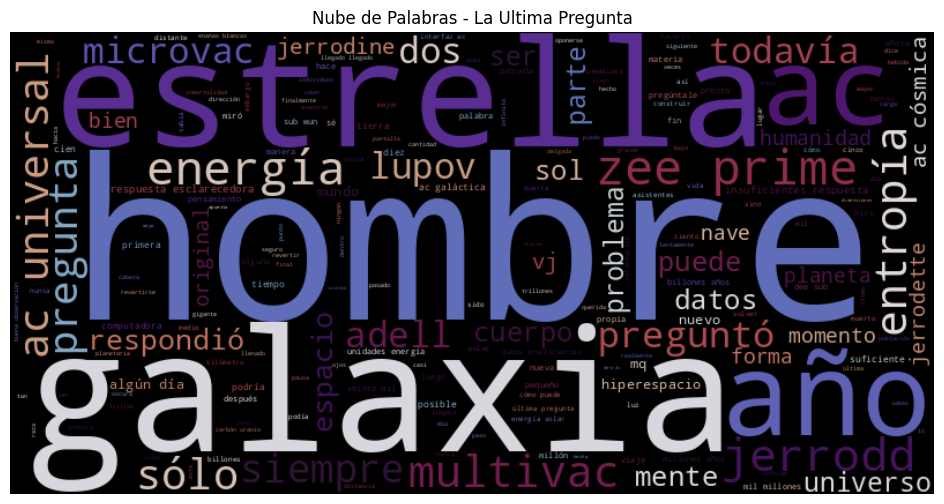

In [77]:
# Importamos las herramientas necesarias para generar la nube
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generamos la nube de palabras
nube = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="twilight"
).generate(texto_limpio)

# Visualizamos el resultado
plt.figure(figsize=(12, 6))
plt.title("Nube de Palabras - La Ultima Pregunta")
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


Para realizar esta parte del análisis se decidió considerar cada oración del cuento como un documento. Primero se segmenta el texto original en oraciones y luego se realiza el preprocesamiento de cada una, convirtiéndolas a minúsculas, eliminando signos, números y stopwords. De esta manera se conserva la separación entre documentos antes de construir la matriz documento-vocabulario.

*Para esta parte utilicé ChatGPT como apoyo. Fuimos desarrollando el código paso a paso y analizando línea por línea qué hacía cada instrucción antes de continuar. Esto me permitió comprender cómo separar el texto en oraciones, limpiar cada una, eliminar stopwords y volver a formar los documentos procesados.*

In [83]:
# Importamos la herramienta para dividir el texto en oraciones
from nltk.tokenize import sent_tokenize

# Descargamos los recursos necesarios para la tokenización
nltk.download("punkt")
nltk.download("punkt_tab")

# Dividimos el cuento en oraciones y las convertimos a minúsculas
oraciones = sent_tokenize(cuento_original.lower(), language="spanish")

print("\nCantidad de oraciones obtenidas:", len(oraciones))

# Limpiamos cada oración
oraciones_limpias = []

for oracion in oraciones:

    # Extraemos únicamente palabras, eliminando números y signos
    palabras_oracion = re.findall(r"\b[a-záéíóúüñ]+\b", oracion)

    palabras_filtradas = []

    # Eliminamos las stopwords
    for palabra in palabras_oracion:
        if palabra not in stopwords_es:
            palabras_filtradas.append(palabra)

    # Volvemos a unir las palabras de cada documento
    oracion_limpia = " ".join(palabras_filtradas)

    # Guardamos solamente las oraciones que no quedaron vacías
    if oracion_limpia:
        oraciones_limpias.append(oracion_limpia)

print("\nCantidad de documentos después de la limpieza:", len(oraciones_limpias))

# Mostramos algunos documentos para comprobar el resultado
for i in range(5):
    print(f"\nDocumento {i}: {oraciones_limpias[i]}")


Cantidad de oraciones obtenidas: 360

Cantidad de documentos después de la limpieza: 350

Documento 0: última pregunta formuló primera medio broma mayo momentos humanidad primera bañó luz

Documento 1: pregunta llegó resultado apuesta cinco dólares hecha dos hombres bebían cerveza sucedió manera alexander adell bertram lupov dos fieles asistentes multivac

Documento 2: dentro dimensiones humano sabían pasaba detrás rostro frío parpadeante intermitentemente luminoso kilómetros kilómetros rostro gigantesca computadora

Documento 3: menos vaga noción plan general circuitos retransmisores hacía tiempo superado posibilidad ser dominados sola persona

Documento 4: multivac autoajustaba autocorregía


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



#### 2.3.2 Determina la longitud de tu vocabulario.

In [89]:
# Importamos las herramientas necesarias para construir y visualizar la matriz
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Creamos el vectorizador
vectorizador = CountVectorizer()

# Construimos la matriz documento-vocabulario
matriz = vectorizador.fit_transform(oraciones_limpias)

# Obtenemos las palabras que forman el vocabulario
vocabulario = vectorizador.get_feature_names_out()

# Mostramos las dimensiones de la matriz
print("Dimensiones de la matriz:", matriz.shape)
print("---"*50)

# Convertimos la matriz en un DataFrame para facilitar su visualización
df_matriz = pd.DataFrame(
    matriz.toarray(),
    columns=vocabulario
)

df_matriz.head()

Dimensiones de la matriz: (350, 1174)
------------------------------------------------------------------------------------------------------------------------------------------------------


,abandonar,abarcó,abastecerla,abrió,absoluto,ac,acompañado,acontecimiento,acopio,acostarse,...,árboles,época,ése,ésta,éstas,éste,última,única,únicas,único
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [90]:
# Longitud del vocabulario
longitud_vocabulario = len(vocabulario)

print("Longitud del vocabulario:", longitud_vocabulario)

Longitud del vocabulario: 1174



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

Una vez construida la matriz documento-vocabulario, se aplica TF-IDF para ponderar la importancia de cada término. Esta medida tiene en cuenta tanto la frecuencia de una palabra dentro de un documento como la cantidad de documentos en los que aparece. De esta manera, los términos muy frecuentes en todo el corpus reciben menor peso, mientras que aquellos más característicos de determinados documentos pueden adquirir mayor relevancia.

In [92]:
# Importamos la herramienta para aplicar TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer

# Creamos el transformador TF-IDF
transformador_tfidf = TfidfTransformer()

# Aplicamos TF-IDF sobre la matriz documento-vocabulario
matriz_tfidf = transformador_tfidf.fit_transform(matriz)

# Mostramos las dimensiones de la nueva matriz
print("Dimensiones de la matriz TF-IDF:", matriz_tfidf.shape)
print("---"*50)

# Convertimos la matriz en un DataFrame para facilitar su visualización
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario
)

df_tfidf.head()

Dimensiones de la matriz TF-IDF: (350, 1174)
------------------------------------------------------------------------------------------------------------------------------------------------------


,abandonar,abarcó,abastecerla,abrió,absoluto,ac,acompañado,acontecimiento,acopio,acostarse,...,árboles,época,ése,ésta,éstas,éste,última,única,únicas,único
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.239316,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [97]:
# Calculamos el peso TF-IDF promedio de cada término
pesos_promedio = df_tfidf.mean(axis=0).sort_values(ascending=False)

print("Palabras con mayor peso TF-IDF promedio:")
print(pesos_promedio.head(10))

Palabras con mayor peso TF-IDF promedio:
ac           0.029515
años         0.022327
hombre       0.020688
energía      0.017757
galaxia      0.017602
estrellas    0.017534
siempre      0.015977
jerrodd      0.014548
entropía     0.014546
zee          0.014212
dtype: float64


La matriz TF-IDF conserva las dimensiones de la matriz documento-vocabulario, ya que continúa representando los mismos documentos y términos. Sin embargo, sus valores ya no representan cantidades de apariciones, sino el peso de cada palabra dentro de cada documento.

Al calcular el peso promedio de los términos en todos los documentos, aparecen entre los valores más altos palabras relacionadas con los principales temas del cuento, como `energía`, `galaxia`, `estrellas` y `entropía`. También aparecen términos propios del relato, como `ac` y `jerrodd`, que adquieren relevancia por su presencia particular dentro del corpus.

# Conclusiones

Lo que más me llamó la atención de este trabajo fue el funcionamiento de TF-IDF. A diferencia de analizar solamente la frecuencia de las palabras, este método también tiene en cuenta cuánto se repite cada término en el conjunto de documentos. Por eso, las palabras que aparecen muchas veces pueden perder peso, mientras que otras menos repetidas pero más representativas pueden destacarse más. Me pareció interesante porque permite analizar el texto de una forma más completa y no quedarse solamente con un conteo de frecuencias.

Además, el trabajo me permitió ver todo el proceso desde la extracción del texto de una página web hasta su limpieza, la construcción de la matriz documento-vocabulario y finalmente la aplicación de TF-IDF. Me resultó útil para entender cómo un texto puede transformarse en datos y ser analizado de manera más objetiva.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

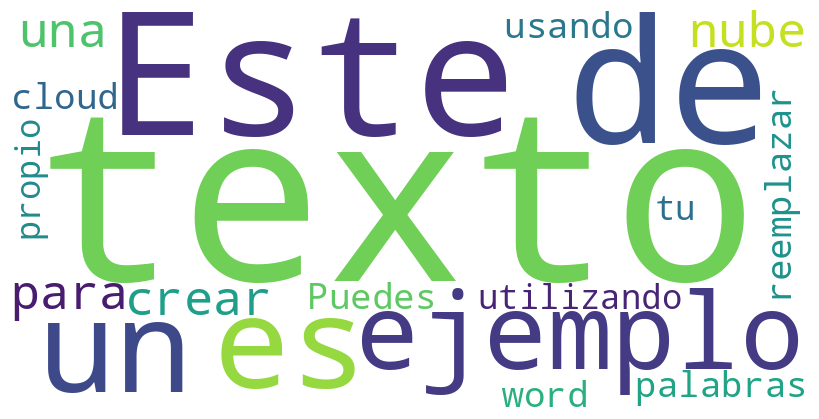

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



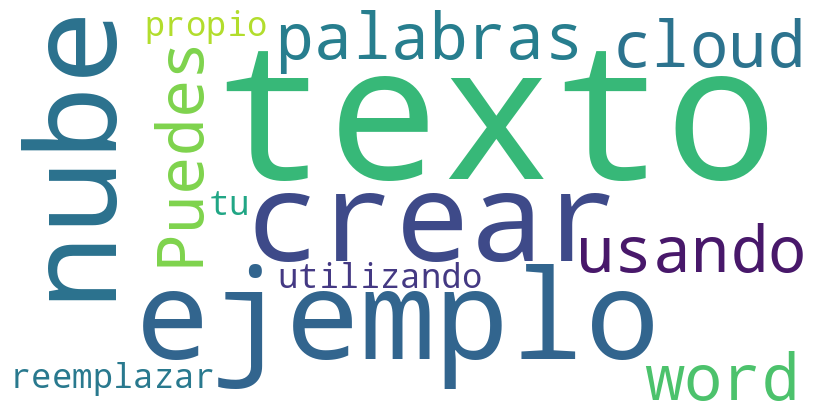

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
